# Concept Basis — Visualisation

Loads a checkpoint produced by `concept_basis.py` and visualises:

1. **Initial Fourier atoms** $\psi_{k_1,k_2,c}$ — the source dictionary.
2. **Learned (pushed-forward) atoms** $Q_\theta\psi_{k_1,k_2,c}$ — the concept basis.
3. **Random K-sparse combinations** $\sum_j c_j\,Q_\theta\psi_j$ — what the SDS loss actually sees during training.

In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.insert(0, "..")
os.chdir("..")

import torch
import numpy as np
import matplotlib.pyplot as plt

## 1. Load checkpoint

Point `CHECKPOINT_DIR` to a directory produced by `concept_basis.py`.
The directory must contain `config.yaml` and `best.pt` (or `latest.pt`).

In [2]:
import yaml
from omegaconf import OmegaConf
from hydra.utils import instantiate
from infidictionary.neural_isometries import NeuralIsometry
from infidictionary.dictionaries import InfiDictionary
from infidictionary.domain_samplers import SquareSampler
from infidictionary.networks import NeuralField

# ── Point to a checkpoint ─────────────────────────────────────────────────────
NAME = "CLIP"
CHECKPOINT_DIR  = "./outputs/checkpoints/wandb-rtcno1s1" # the CLIP
CHECKPOINT_FILE = "step_440.pt"


NAME = "SDS"
CHECKPOINT_DIR  = "./outputs/checkpoints/wandb-ezfchg36" # just mean after fixing with Artem
CHECKPOINT_FILE = "step_10000.pt"

NAME = "SDS"
CHECKPOINT_DIR  = "./outputs/checkpoints/wandb-gci5jilo" # working cat SDS with mean
CHECKPOINT_FILE = "step_160.pt"

NAME = "SDS"
CHECKPOINT_DIR  = "./outputs/checkpoints/wandb-yr6idha3" # cat without mean working well
CHECKPOINT_FILE = "step_310.pt"

NAME = "SDS"
CHECKPOINT_DIR  = "./outputs/checkpoints/wandb-hpw1lnb2" # Van Gogh without mean
CHECKPOINT_FILE = "step_120.pt"


NAME = "SDS"
CHECKPOINT_DIR  = "./outputs/checkpoints/wandb-kwdd26bp" # Joseph without mean
CHECKPOINT_FILE = "step_20.pt"

# ─────────────────────────────────────────────────────────────────────────────

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with open(f"{CHECKPOINT_DIR}/config.yaml") as f:
    conf = OmegaConf.create(yaml.safe_load(f))

neural_isometry: NeuralIsometry    = instantiate(conf.neural_isometry).to(device)
initial_dictionary: InfiDictionary = instantiate(conf.initial_dictionary)
variation_strength = conf.get("variation_strength", 0)

# Load mean_function if it was part of the training config
mean_function: NeuralField | None = None
if conf.get("mean_function") is not None:
    mean_function = instantiate(conf.mean_function).to(device)

ckpt = torch.load(f"{CHECKPOINT_DIR}/{CHECKPOINT_FILE}", map_location=device, weights_only=False)
neural_isometry.load_state_dict(ckpt["models"]["neural_isometry"])
if mean_function is not None and "mean_function" in ckpt.get("models", {}):
    mean_function.load_state_dict(ckpt["models"]["mean_function"])
    print("Loaded mean_function weights.")
elif mean_function is not None:
    print("Warning: mean_function in config but not found in checkpoint — using random init.")

model_state_kwargs = dict(conf.get("model_state_kwargs", {"num_steps": 200}))
pushforward_kwargs = dict(conf.get("pushforward_kwargs", {}))
neural_isometry.shuffle_model_state(**model_state_kwargs)
neural_isometry.eval()
if mean_function is not None:
    mean_function.eval()

print(f"Loaded : {CHECKPOINT_DIR}/{CHECKPOINT_FILE}")
print(f"  epoch  : {ckpt.get('epoch')}  |  metric : {ckpt.get('metric', float('nan')):.4f}")

Loaded : ./outputs/checkpoints/wandb-kwdd26bp/step_20.pt
  epoch  : 19  |  metric : 0.3872


## 2. Evaluate atoms on a dense grid

Evaluate both the initial Fourier atoms and their pushforward on a `N_PER_DIM × N_PER_DIM`
regular grid.  `NUM_TRUNCATED` is the L∞ half-bandwidth; it gives
$(2 \cdot \text{NUM\_TRUNCATED}+1)^2 \times 3$ atoms in total.

In [3]:
NUM_TRUNCATED = 3   # L∞ half-bandwidth → (2·3+1)² = 49 spatial atoms × 3 channels = 147 total
N_PER_DIM     = 200

indices = initial_dictionary.get_truncated_indices(num_truncated=NUM_TRUNCATED).to(device)
print(f"Indices : {indices.shape}  "
      f"(spatial {indices[:, :-1].min()}..{indices[:, :-1].max()}, "
      f"channels {indices[:, -1].unique().tolist()})")

# SquareSampler(stratified=True, add_noise=False) produces an exact regular grid
# with indexing='ij': coords[i*n+j] = (x_i, y_j), i.e. x varies along the slow
# (outer) axis.  When reshaping to (n, n, C) the first axis is x (→ rows of the
# image array) and the second is y (→ columns).  We flip axis-0 in atom_as_img
# so that increasing y points upward in imshow, matching a standard plot.
grid_coords    = SquareSampler(stratified=True, add_noise=False).sample(N_PER_DIM).to(device)
grid_logabsdet = torch.zeros(grid_coords.shape[0], device=device)

with torch.no_grad():
    grid_atoms = initial_dictionary.get_atoms(grid_coords, indices)   # (A, N, 3)
    _, _, grid_deformed = neural_isometry.pushforward(
        src_coords=grid_coords,
        src_logabsdet=grid_logabsdet,
        src_field=grid_atoms,
        **pushforward_kwargs,
    )   # (A, N, 3)

    # Evaluate the mean function on the same grid if available.
    # Apply tanh to match the training loop: concept_basis.py applies tanh as an
    # output activation before passing to the concept loss (prevents dead zones
    # from clamp and bounds output to (-1, 1) regardless of raw network values).
    if mean_function is not None:
        mean_vals = mean_function(grid_coords).tanh()   # (N, C), in (-1, 1)
        mean_img_np = mean_vals.reshape(N_PER_DIM, N_PER_DIM, -1).cpu().numpy()
    else:
        mean_img_np = None

grid_atoms_np    = grid_atoms.cpu().numpy()    # (A, N, 3)
grid_deformed_np = grid_deformed.cpu().numpy() # (A, N, 3)
print(f"grid_atoms:    {grid_atoms_np.shape}")
print(f"grid_deformed: {grid_deformed_np.shape}")
if mean_img_np is not None:
    print(f"mean_img:      {mean_img_np.shape}  "
          f"range [{mean_img_np.min():.3f}, {mean_img_np.max():.3f}]")

Indices : torch.Size([75, 3])  (spatial -2..2, channels [0, 1, 2])
grid_atoms:    (75, 40000, 3)
grid_deformed: (75, 40000, 3)


## 3. Triptych visualisation

Each panel shows one RGB channel.  Rows = $k_1$ values, columns = $k_2$ values.
Values are clamped to $[-1,1]$ and rescaled to $[0,1]$ for display.

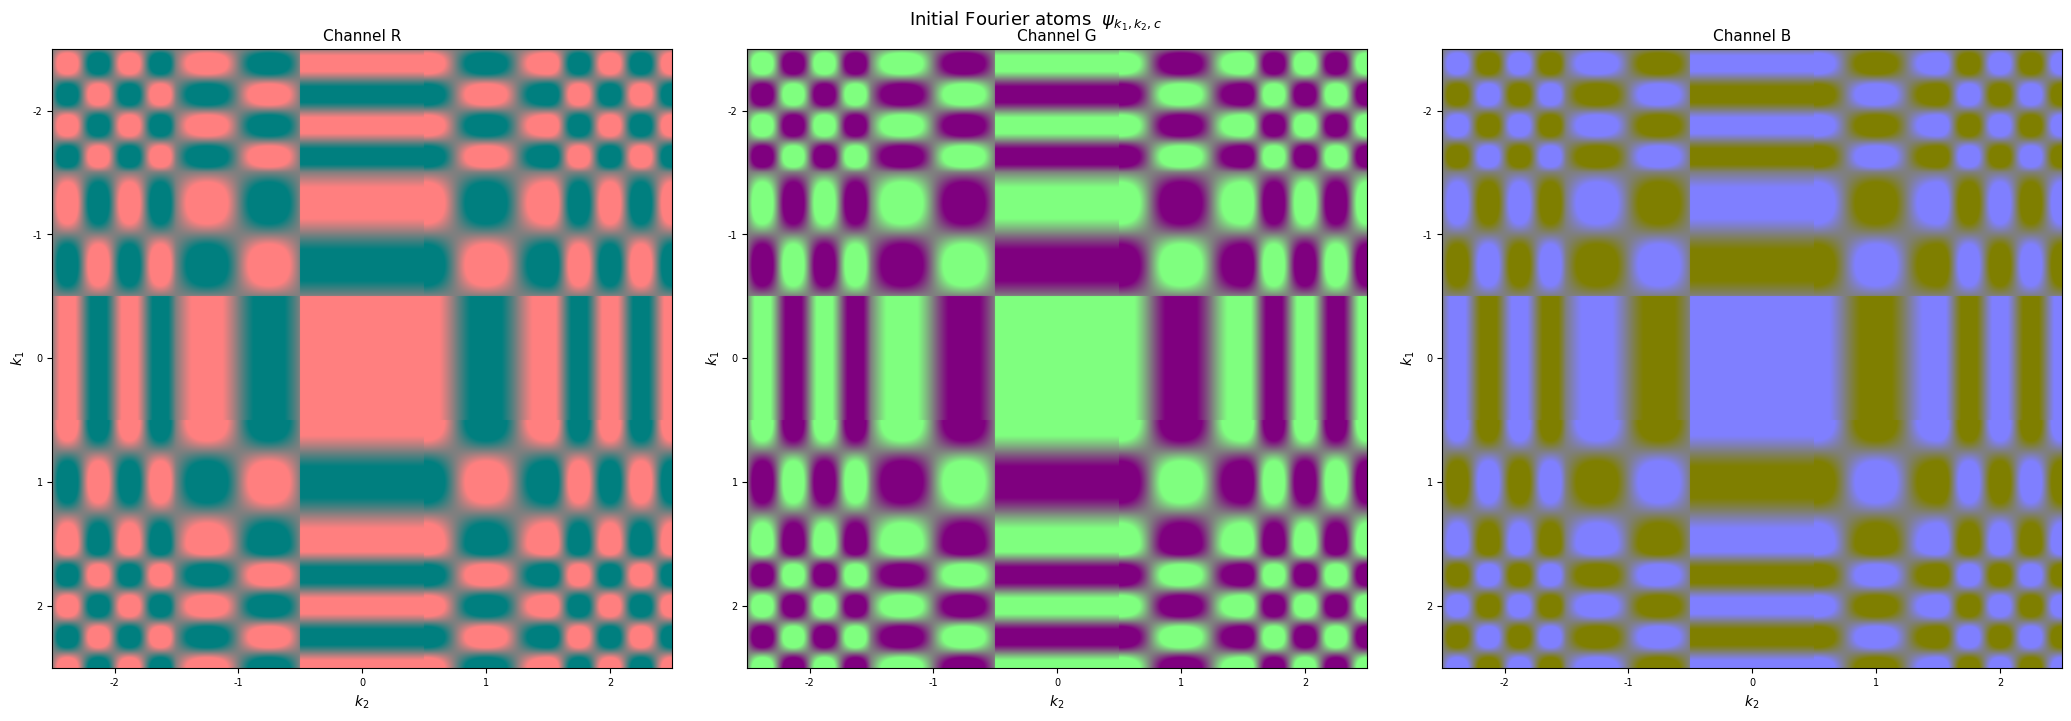

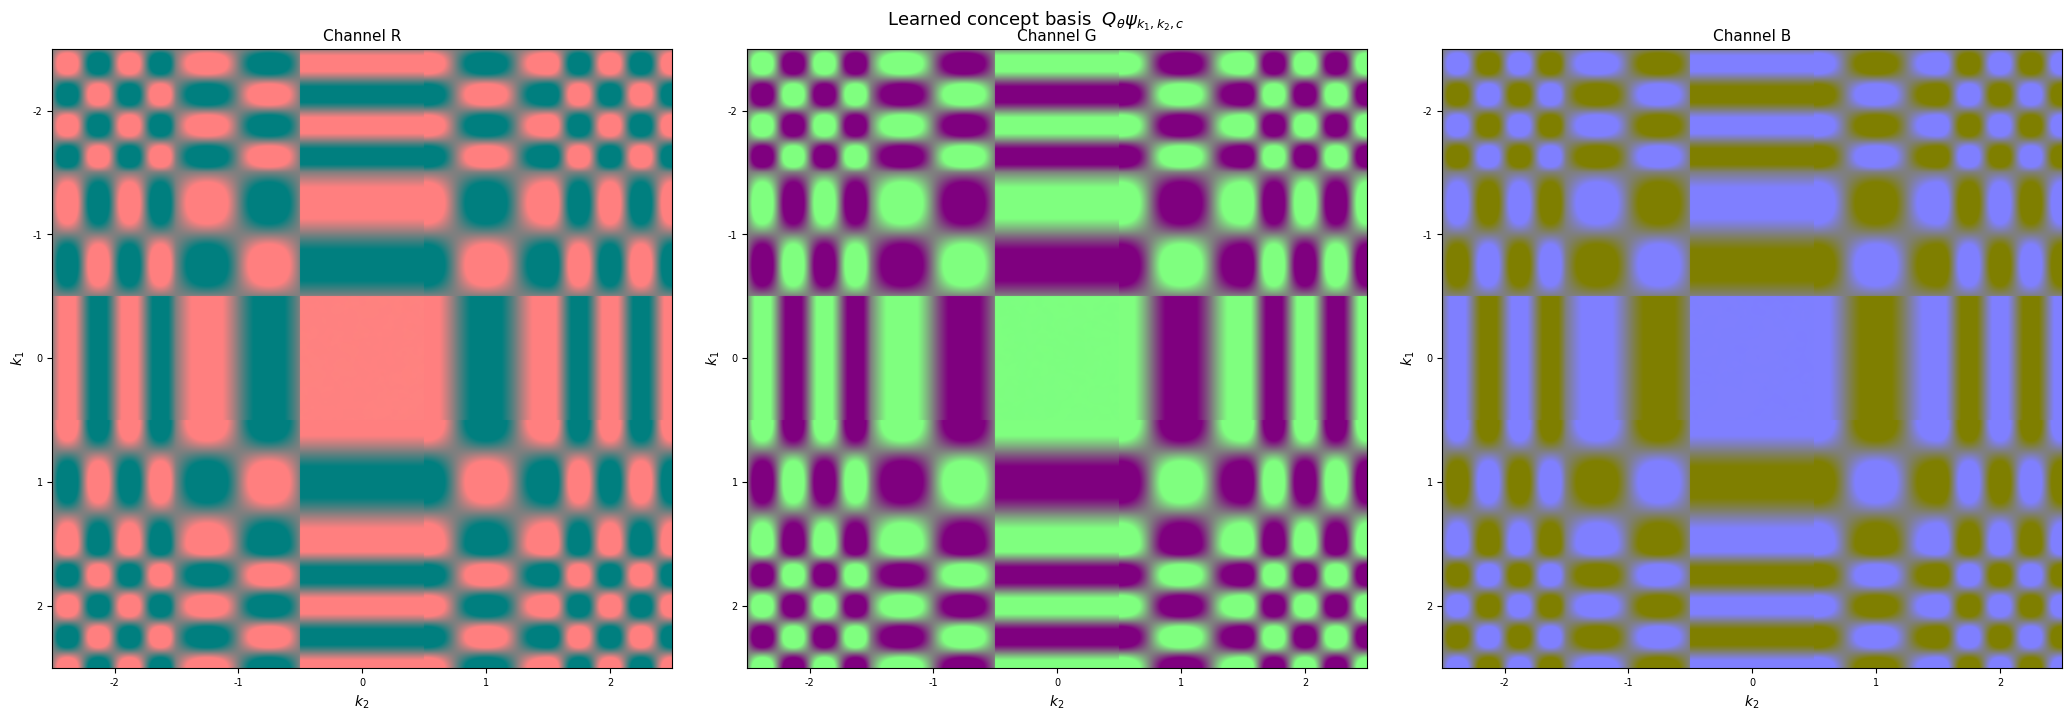

In [4]:
idx_np  = indices.cpu().numpy()   # (A, 3)
k1_vals = sorted(set(idx_np[:, 0].tolist()))
k2_vals = sorted(set(idx_np[:, 1].tolist()))
ch_names_rgb = ["R", "G", "B"]

lookup = {(int(idx_np[i, 0]), int(idx_np[i, 1]), int(idx_np[i, 2])): i
          for i in range(len(idx_np))}


def atom_as_img(atoms_arr: np.ndarray, i: int, n: int) -> np.ndarray:
    """Return atom i as an (n, n, 3) float array ready for imshow.

    SquareSampler uses indexing='ij' so x is the slow axis; after reshape to
    (n, n, 3) the first axis is x (rows).  We flip axis-0 so that y increases
    upward when displayed with origin='lower'.
    Values are clamped to [-1, 1] and rescaled to [0, 1].
    """
    raw    = atoms_arr[i].reshape(n, n, 3)
    processed =  (np.clip(raw, -1, 1) + 1) / 2
    return np.flip(processed, axis=0)


def make_mosaic(atoms_arr: np.ndarray, channel: int, n: int) -> np.ndarray:
    """Tile per-atom images into a (|k1|·n, |k2|·n, 3) mosaic."""
    n_k1, n_k2 = len(k1_vals), len(k2_vals)
    mosaic = np.zeros((n_k1 * n, n_k2 * n, 3))
    for ri, k1 in enumerate(reversed(k1_vals)):
        for ci, k2 in enumerate(k2_vals):
            key = (int(k1), int(k2), channel)
            if key in lookup:
                mosaic[ri*n:(ri+1)*n, ci*n:(ci+1)*n] = atom_as_img(atoms_arr, lookup[key], n)
    return mosaic


def plot_triptych(atoms_arr: np.ndarray, title: str, n: int) -> None:
    """One figure with 3 panels (R/G/B), each a k1×k2 frequency mosaic."""
    fig, axes = plt.subplots(1, 3, figsize=(21, 7))
    k1_rev = list(reversed(k1_vals))

    for c, (ax, ch) in enumerate(zip(axes, ch_names_rgb)):
        mosaic = make_mosaic(atoms_arr, c, n)
        ax.imshow(mosaic, origin="lower")
        ax.set_title(f"Channel {ch}", fontsize=11)
        ax.set_xticks([ci * n + n // 2 for ci in range(len(k2_vals))])
        ax.set_xticklabels([str(int(k)) for k in k2_vals], fontsize=7)
        ax.set_xlabel("$k_2$")
        ax.set_yticks([ri * n + n // 2 for ri in range(len(k1_vals))])
        ax.set_yticklabels([str(int(k)) for k in k1_rev], fontsize=7)
        ax.set_ylabel("$k_1$")

    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()


plot_triptych(grid_atoms_np,    "Initial Fourier atoms  $\\psi_{k_1,k_2,c}$",          N_PER_DIM)
plot_triptych(grid_deformed_np, "Learned concept basis  $Q_\\theta\\psi_{k_1,k_2,c}$", N_PER_DIM)

# ── Mean function ─────────────────────────────────────────────────────────────
if mean_img_np is not None:
    mean_display = (np.clip(np.flip(mean_img_np, axis=0), -1, 1) + 1) / 2  # flip y, rescale

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))

    axes[0].imshow(mean_display, origin="lower")
    axes[0].set_title("RGB composite  $\\mu_\\phi(x)$", fontsize=11)
    axes[0].axis("off")

    for c, (ax, ch) in enumerate(zip(axes[1:], ch_names_rgb)):
        ax.imshow(mean_display[:, :, c], origin="lower", cmap="RdBu_r", vmin=0, vmax=1)
        ax.set_title(f"Channel {ch}", fontsize=11)
        ax.axis("off")

    fig.suptitle(
        "Learned mean function  $\\mu_\\phi$  "
        f"(range [{mean_img_np.min():.2f}, {mean_img_np.max():.2f}])",
        fontsize=13,
    )
    plt.tight_layout()
    plt.show()

## 4. Random K-sparse combinations

Sample several random sets of K atom indices and decayed coefficients
— exactly as done in training — and render $\sum_j c_j\,Q_\theta\psi_j$.
If a mean function was trained, it is added to each combination before display,
showing the full image $\mu_\phi(x) + \sum_j c_j\,Q_\theta\psi_j$ as the concept loss sees it.

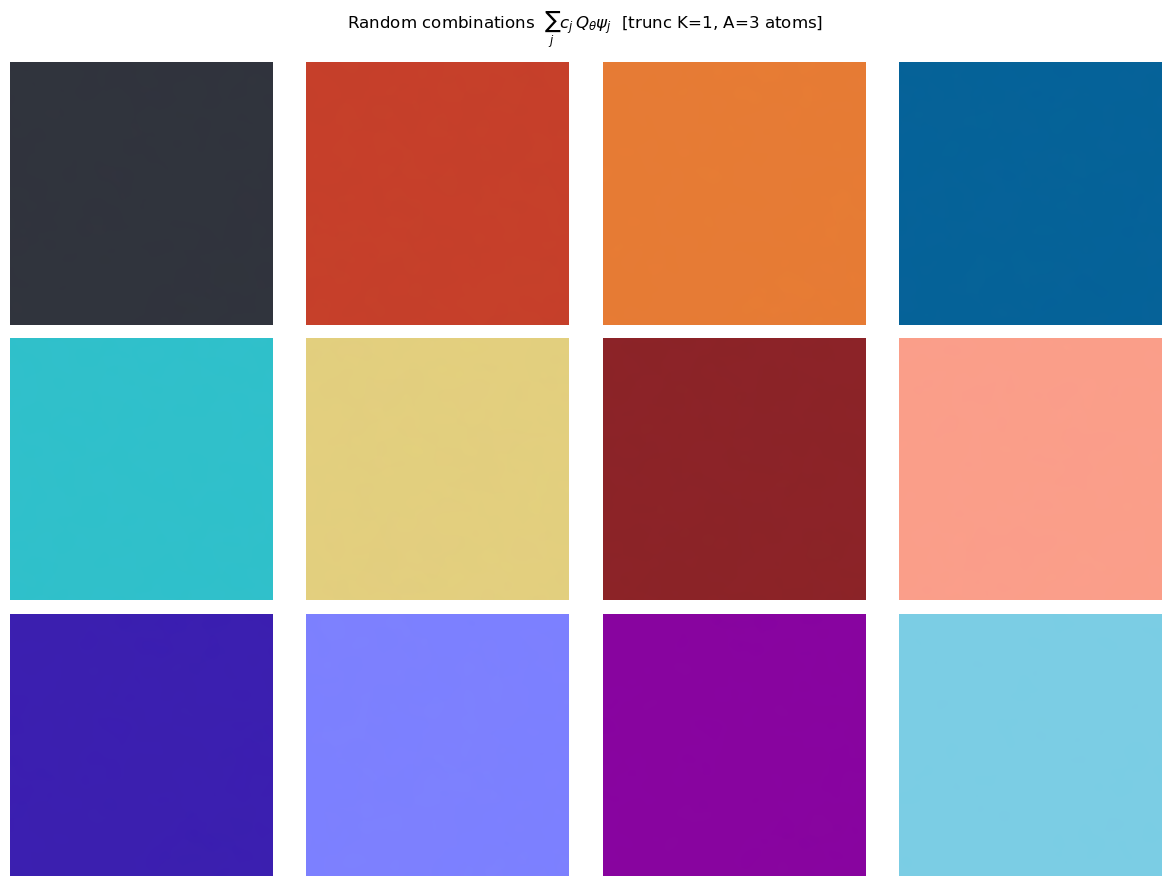

In [5]:
K                 = int(conf.get("K", 1))
K = 1
coefficient_decay = float(conf.get("coefficient_decay", 0.5))
N_COMBINATIONS    = 12   # number of random combinations to display
N_COLS            = 4

# ── Mirror training exactly ───────────────────────────────────────────────────
# 1. Fix the truncated index set (same as training: K is a truncation level,
#    giving (2K+1)² × C atoms, NOT a random sample of K atoms).
indices_vis = initial_dictionary.get_truncated_indices(num_truncated=K).to(device)  # (A, d+1)
pmfs_vis    = initial_dictionary.get_index_pmfs(indices_vis).to(device)             # (A,)
A_vis       = indices_vis.shape[0]
coeff_std   = pmfs_vis.pow(coefficient_decay)                                        # (A,)

# 2. Evaluate initial atoms and push forward once (indices are fixed per epoch).
with torch.no_grad():
    init_atoms_vis = initial_dictionary.get_atoms(grid_coords, indices_vis)  # (A, N, C)
    _, _, pushed_vis = neural_isometry.pushforward(
        src_coords=grid_coords,
        src_logabsdet=grid_logabsdet,
        src_field=init_atoms_vis,
        **pushforward_kwargs,
    )  # (A, N, C)

    # 3. Sample N_COMBINATIONS independent coefficient vectors at once and form
    #    all combinations via einsum — matches training's batched path exactly.
    coeffs_all = torch.randn(N_COMBINATIONS, A_vis, device=device) * coeff_std  # (B, A)
    coeffs_all = coeffs_all / torch.norm(coeffs_all, dim=-1, keepdim=True)
    combos     = torch.einsum("ba,anc->bnc", coeffs_all, pushed_vis)            # (B, N, C)

    # 4. Add mean_function if available (affine subspace: mean + linear variation).
    # Apply tanh to mean_function output to match training: concept_basis.py uses
    # tanh as output activation (raw_output.tanh()) before combining with atoms.
    if mean_function is not None:
        mean_vals_vis = mean_function(grid_coords).tanh()   # (N, C), in (-1, 1)
        combos = combos * variation_strength + mean_vals_vis.unsqueeze(0)        # (B, N, C)

C_vis     = combos.shape[-1]
combos_np = combos.reshape(N_COMBINATIONS, N_PER_DIM, N_PER_DIM, C_vis).cpu().numpy()
# Flip y-axis so y increases upward; clamp to [-1,1] and rescale to [0,1] for imshow.
combos_np = (np.clip(np.flip(combos_np, axis=1), -1, 1) + 1) / 2

has_mean = mean_function is not None
title_suffix = r"  $+\;\mu_\phi$" if has_mean else ""

n_rows = (N_COMBINATIONS + N_COLS - 1) // N_COLS
fig, axes = plt.subplots(n_rows, N_COLS, figsize=(N_COLS * 3, n_rows * 3))
axes = axes.flatten()
for ax, img in zip(axes, combos_np):
    ax.imshow(np.clip(img, 0, 1), origin="lower")
    ax.axis("off")
for ax in axes[N_COMBINATIONS:]:
    ax.axis("off")

fig.suptitle(
    f"Random combinations  $\\sum_j c_j\\,Q_\\theta\\psi_j${title_suffix}  "
    f"[trunc K={K}, A={A_vis} atoms]",
    fontsize=12,
)
plt.tight_layout()
plt.show()